/tmp/ipykernel_75652/2780136489.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_75652/2780136489.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


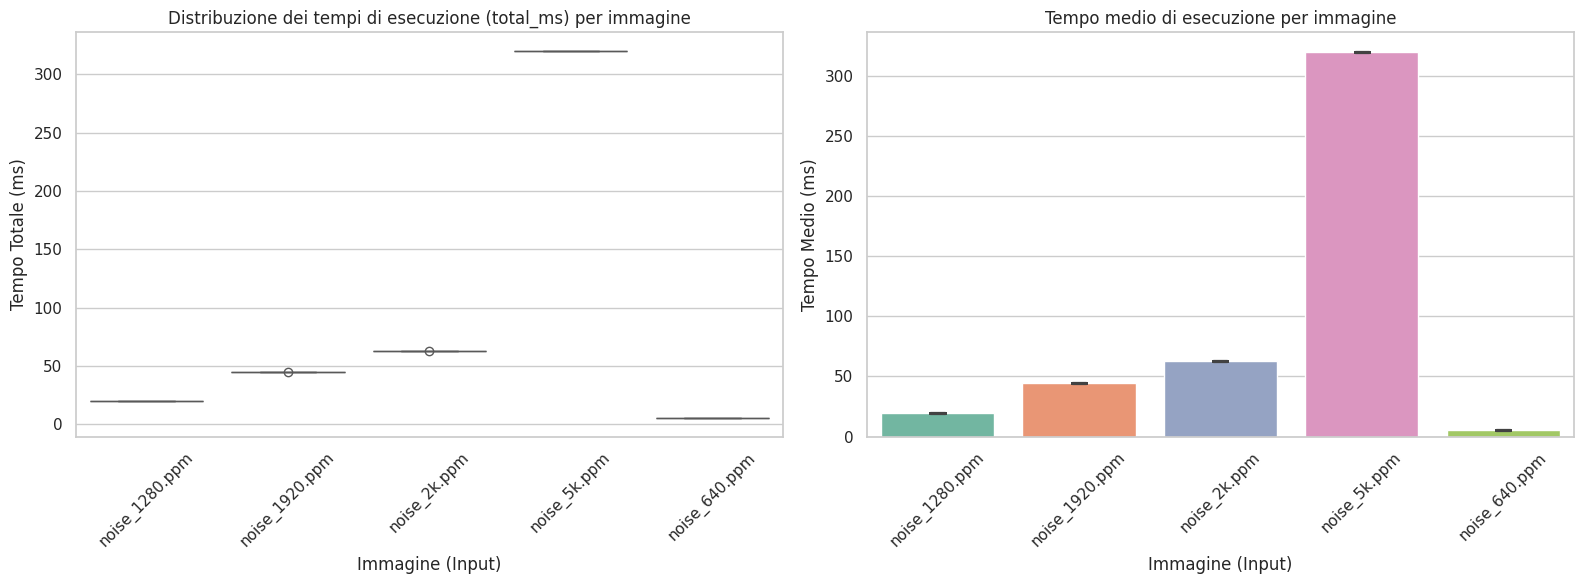

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carica i dati dal file CSV
# Sostituisci 'denoise_1.csv' con il percorso corretto se il file è in un'altra cartella
df = pd.read_csv('denoise_1.csv')

# (Opzionale) Pulisci i dati tenendo solo le esecuzioni con status 'ok'
df = df[df['status'] == 'ok']

# Imposta lo stile di Seaborn per grafici più eleganti
sns.set_theme(style="whitegrid")

# Crea una figura con due sotto-grafici (1 riga, 2 colonne)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- GRAFICO 1: Boxplot dei tempi totali per ogni immagine ---
# Mostra la distribuzione, la mediana e gli eventuali valori anomali dei tempi (total_ms)
sns.boxplot(
    data=df, 
    x='image', 
    y='total_ms', 
    ax=axes[0],
    palette='Set2'
)
axes[0].set_title('Distribuzione dei tempi di esecuzione (total_ms) per immagine')
axes[0].set_xlabel('Immagine (Input)')
axes[0].set_ylabel('Tempo Totale (ms)')
axes[0].tick_params(axis='x', rotation=45) # Ruota le etichette dell'asse x per leggerle meglio

# --- GRAFICO 2: Grafico a barre del tempo medio di esecuzione ---
# Calcola la media e mostra la deviazione standard come barra di errore
sns.barplot(
    data=df, 
    x='image', 
    y='total_ms', 
    ax=axes[1],
    palette='Set2',
    capsize=0.1
)
axes[1].set_title('Tempo medio di esecuzione per immagine')
axes[1].set_xlabel('Immagine (Input)')
axes[1].set_ylabel('Tempo Medio (ms)')
axes[1].tick_params(axis='x', rotation=45)

# Aggiusta il layout per evitare che le scritte si sovrappongano
plt.tight_layout()

# Mostra il grafico
plt.show()

C:\Users\marra\AppData\Local\Temp\ipykernel_2912\798272536.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


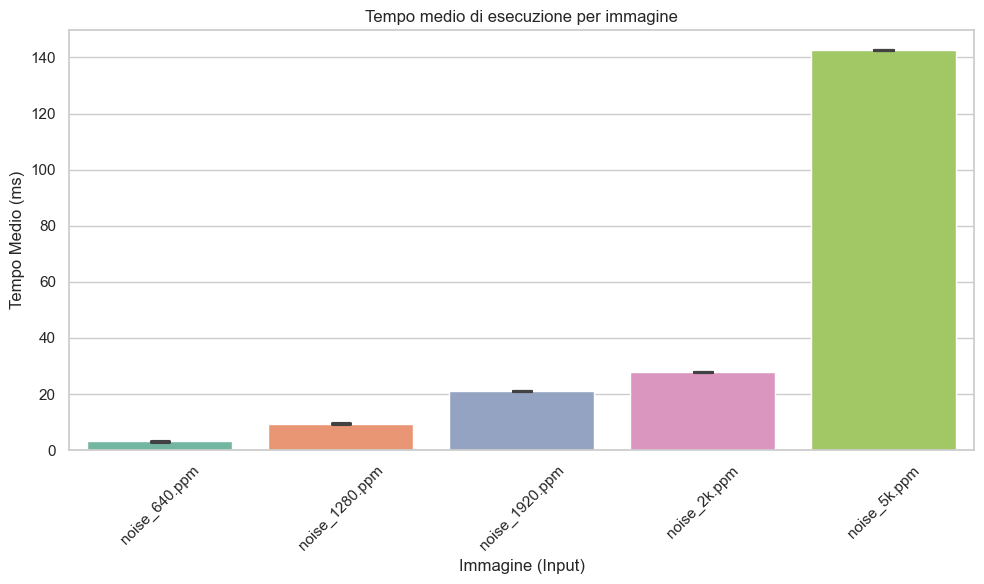

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carica i dati dal file CSV
df = pd.read_csv('denoise_1_3_new.csv')

# Filtra solo le esecuzioni con status 'ok'
df = df[df['status'] == 'ok']

# 2. Definisci l'ordine personalizzato per l'asse X
# Recuperiamo tutti i nomi unici delle immagini
immagini = df['image'].unique().tolist()

# Cerchiamo l'immagine che contiene '640' e la spostiamo all'inizio della lista
nome_640 = next((img for img in immagini if '640' in str(img)), None)
if nome_640 and nome_640 in immagini:
    immagini.remove(nome_640)
    immagini.insert(0, nome_640) # Inserisce in prima posizione (indice 0)

# Imposta lo stile
sns.set_theme(style="whitegrid")

# Crea una singola figura
plt.figure(figsize=(10, 6))

# --- GRAFICO: a barre del tempo medio di esecuzione ---
sns.barplot(
    data=df, 
    x='image', 
    y='total_ms', 
    order=immagini,      # <--- Questo parametro forza l'ordine che abbiamo deciso sopra
    palette='Set2',
    capsize=0.1
)

# Imposta titoli ed etichette
plt.title('Tempo medio di esecuzione per immagine')
plt.xlabel('Immagine (Input)')
plt.ylabel('Tempo Medio (ms)')
plt.xticks(rotation=45) # Ruota il testo per renderlo leggibile

# Aggiusta i margini
plt.tight_layout()

# Mostra il grafico
plt.show()

In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definisci l'array dei file CSV da elaborare e la cartella di destinazione
# Sostituisci questi nomi con i percorsi reali dei tuoi file
lista_csv = ['denoise_1_3_new.csv'] 

cartella_output = 'plots' # Nome della cartella in cui salvare le immagini

# 2. Crea la cartella di destinazione se non esiste già
if not os.path.exists(cartella_output):
    os.makedirs(cartella_output)
    print(f"Cartella '{cartella_output}' creata.")

# Imposta lo stile globale per i grafici
sns.set_theme(style="whitegrid")

# 3. Esegui un ciclo attraverso ogni file nell'array
for file_csv in lista_csv:
    try:
        # Carica i dati
        df = pd.read_csv(file_csv)
        
        # Filtra solo le esecuzioni con status 'ok' (se la colonna esiste)
        if 'status' in df.columns:
            df = df[df['status'] == 'ok']
        
        # Definisci l'ordine personalizzato per l'asse X
        immagini = df['image'].unique().tolist()
        
        # Cerca l'immagine che contiene '640' e spostala all'inizio
        nome_640 = next((img for img in immagini if '640' in str(img)), None)
        if nome_640 and nome_640 in immagini:
            immagini.remove(nome_640)
            immagini.insert(0, nome_640)
        
        # Crea una nuova figura per questo specifico CSV
        plt.figure(figsize=(10, 6))
        
        # Crea il grafico a barre
        sns.barplot(
            data=df, 
            x='image', 
            y='total_ms', 
            order=immagini,
            palette='Set2',
            capsize=0.1
        )
        
        # Ottieni solo il nome del file (senza il percorso) per usarlo nel titolo
        nome_base = os.path.basename(file_csv)
        
        # Imposta titoli ed etichette
        plt.title(f'Tempo medio di esecuzione - {nome_base}')
        plt.xlabel('Immagine (Input)')
        plt.ylabel('Tempo Medio (ms)')
        plt.xticks(rotation=45)
        plt.tight_layout()
        
        # 4. Salva il grafico
        # Crea il nome per il file immagine (es. denoise_1.csv -> grafico_denoise_1.png)
        nome_immagine = f"grafico_{nome_base.replace('.csv', '.png')}"
        percorso_salvataggio = os.path.join(cartella_output, nome_immagine)
        
        # Salva l'immagine nella cartella (dpi=300 garantisce un'ottima risoluzione)
        plt.savefig(percorso_salvataggio, dpi=300)
        print(f"✅ Grafico salvato con successo: {percorso_salvataggio}")
        
        # 5. IMPORTANTE: Chiudi la figura per liberare la memoria 
        # e per evitare che il prossimo grafico si sovrapponga a questo!
        plt.close()
        
    except FileNotFoundError:
        print(f"❌ Errore: Il file '{file_csv}' non è stato trovato.")
    except Exception as e:
        print(f"❌ Si è verificato un errore processando '{file_csv}': {e}")

print("Elaborazione completata!")

C:\Users\marra\AppData\Local\Temp\ipykernel_2912\4173936023.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


✅ Grafico salvato con successo: plots\grafico_denoise_1_3_new.png
Elaborazione completata!


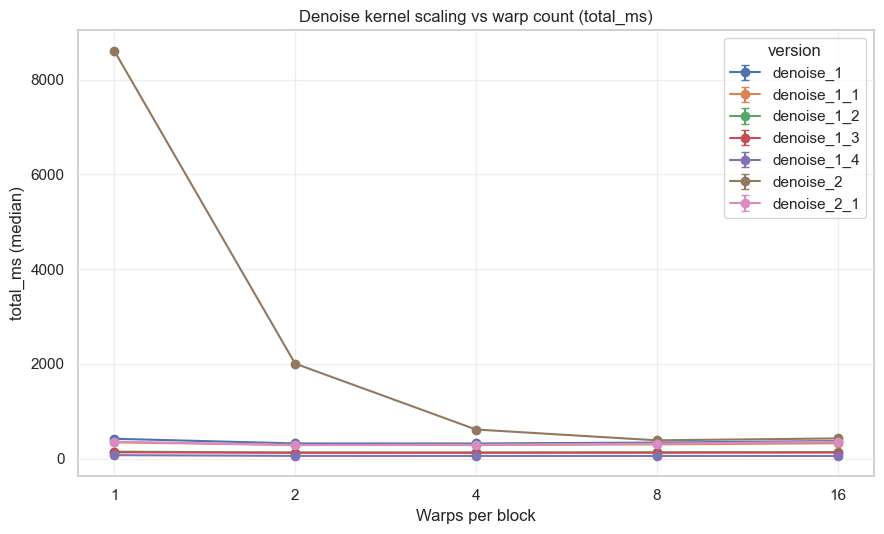

       base  warps    median        mean       std      min      max
  denoise_1      1  422.2440  422.249450  0.035116  422.189  422.330
  denoise_1      2  322.9730  322.975400  0.073160  322.810  323.141
  denoise_1      4  322.4815  322.476150  0.054747  322.367  322.645
  denoise_1      8  341.2705  341.283150  0.071849  341.144  341.470
  denoise_1     16  374.5760  374.585400  0.070939  374.450  374.842
denoise_1_1      1  346.4925  346.493300  0.031674  346.429  346.594
denoise_1_1      2  289.6605  289.658767  0.049080  289.572  289.759
denoise_1_1      4  289.6690  289.665467  0.050578  289.545  289.764
denoise_1_1      8  303.2545  303.265333  0.062351  303.147  303.403
denoise_1_1     16  327.5690  327.577933  0.044430  327.481  327.671
denoise_1_2      1  149.8960  149.892500  0.061613  149.786  150.051
denoise_1_2      2  131.4830  131.482133  0.058235  131.396  131.608
denoise_1_2      4  132.3795  132.370333  0.050606  132.290  132.468
denoise_1_2      8  135.9580  135.

In [6]:
import glob
import re
import pandas as pd
import matplotlib.pyplot as plt

# --- config ---
METRIC = "total_ms"       # change to "slow_ms", "fast_ms", or "sort_ms" if you prefer
AGG    = "median"         # "median" is robust; "mean" also fine
PATTERN = "denoise_*_warps.csv"

# --- load ---
frames = []
for path in sorted(glob.glob(PATTERN)):
    df = pd.read_csv(path)
    df = df[df["status"] == "ok"]
    # split executable like "denoise_1_2_w4" -> base "denoise_1_2", warps 4
    m = df["executable"].str.extract(r"^(?P<base>.+?)_w(?P<warps>\d+)$")
    df["base"]  = m["base"]
    df["warps"] = m["warps"].astype(int)
    frames.append(df)

data = pd.concat(frames, ignore_index=True)

# --- aggregate per (base, warps) ---
agg = (data.groupby(["base", "warps"])[METRIC]
            .agg(["median", "mean", "std", "min", "max"])
            .reset_index()
            .sort_values(["base", "warps"]))

# --- plot ---
fig, ax = plt.subplots(figsize=(9, 5.5))
for base, sub in agg.groupby("base"):
    ax.errorbar(sub["warps"], sub[AGG],
                yerr=sub["std"], marker="o", capsize=3, label=base)

ax.set_xlabel("Warps per block")
ax.set_ylabel(f"{METRIC} ({AGG})")
ax.set_title(f"Denoise kernel scaling vs warp count ({METRIC})")
ax.set_xscale("log", base=2)
ax.set_xticks(sorted(agg["warps"].unique()))
ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v)}"))
ax.grid(True, alpha=0.3)
ax.legend(title="version", loc="best")
fig.tight_layout()
plt.show()

# optional: print the table
print(agg.to_string(index=False))

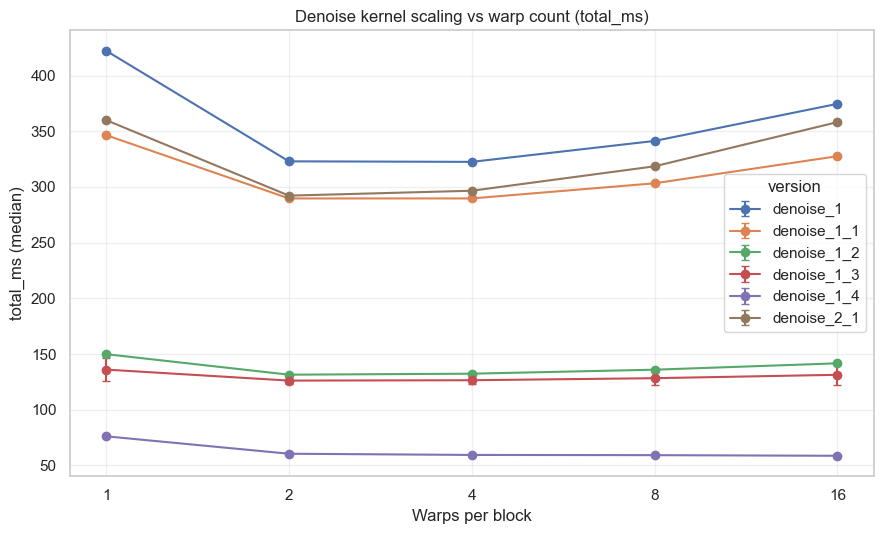

In [8]:
import glob
import re
import pandas as pd
import matplotlib.pyplot as plt

# --- config ---
METRIC = "total_ms"
AGG    = "median"
PATTERN = "denoise_*_warps.csv"
EXCLUDE = {"denoise_2"}   # bases to drop

# --- load ---
frames = []
for path in sorted(glob.glob(PATTERN)):
    df = pd.read_csv(path)
    df = df[df["status"] == "ok"]
    m = df["executable"].str.extract(r"^(?P<base>.+?)_w(?P<warps>\d+)$")
    df["base"]  = m["base"]
    df["warps"] = m["warps"].astype(int)
    frames.append(df)

data = pd.concat(frames, ignore_index=True)

# --- aggregate per (base, warps) ---
agg = (data.groupby(["base", "warps"])[METRIC]
            .agg(["median", "mean", "std", "min", "max"])
            .reset_index()
            .sort_values(["base", "warps"]))

# --- drop excluded versions ---
agg = agg[~agg["base"].isin(EXCLUDE)]

# --- plot ---
fig, ax = plt.subplots(figsize=(9, 5.5))
for base, sub in agg.groupby("base"):
    ax.errorbar(sub["warps"], sub[AGG],
                yerr=sub["std"], marker="o", capsize=3, label=base)

ax.set_xlabel("Warps per block")
ax.set_ylabel(f"{METRIC} ({AGG})")
ax.set_title(f"Denoise kernel scaling vs warp count ({METRIC})")
ax.set_xscale("log", base=2)
ax.set_xticks(sorted(agg["warps"].unique()))
ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v)}"))
ax.grid(True, alpha=0.3)
ax.legend(title="version", loc="best")
fig.tight_layout()
plt.show()

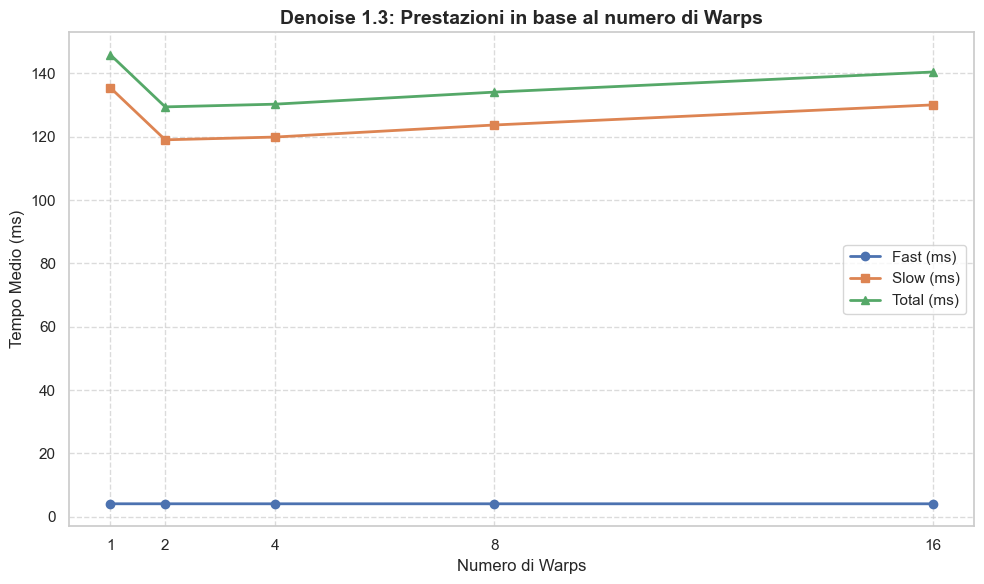

In [9]:
# code for plotting the warps

import pandas as pd
import matplotlib.pyplot as plt

# 1. Caricamento dei dati dal CSV
# Assicurati che il file CSV sia nella stessa cartella del notebook
file_path = 'denoise_1_3_new_warps.csv'
df = pd.read_csv(file_path)

# 2. Pulizia e preparazione dei dati
# Estraiamo il numero di warps dal nome dell'eseguibile. 
# Es: 'denoise_1_3_w16' diventa il numero intero 16
df['warps'] = df['executable'].str.extract(r'w(\d+)$').astype(int)

# Raggruppiamo per numero di warps e calcoliamo il tempo medio su tutte le ripetizioni
df_avg = df.groupby('warps')[['fast_ms', 'slow_ms', 'total_ms']].mean().reset_index()

# Ordiniamo i dati in base al numero di warps per avere un asse X corretto
df_avg = df_avg.sort_values('warps')

# 3. Creazione del grafico
plt.figure(figsize=(10, 6))

# Aggiungiamo le linee per i tre tempi misurati
plt.plot(df_avg['warps'], df_avg['fast_ms'], marker='o', linewidth=2, label='Fast (ms)')
plt.plot(df_avg['warps'], df_avg['slow_ms'], marker='s', linewidth=2, label='Slow (ms)')
plt.plot(df_avg['warps'], df_avg['total_ms'], marker='^', linewidth=2, label='Total (ms)')

# 4. Personalizzazione estetica (per renderlo simile al tuo)
plt.title('Denoise 1.3: Prestazioni in base al numero di Warps', fontsize=14, fontweight='bold')
plt.xlabel('Numero di Warps', fontsize=12)
plt.ylabel('Tempo Medio (ms)', fontsize=12)

# Impostiamo l'asse X per mostrare esattamente i blocchi di warps testati (es. 1, 16, ecc.)
plt.xticks(df_avg['warps'])

# Aggiungiamo una griglia di sfondo per facilitare la lettura
plt.grid(True, linestyle='--', alpha=0.7)

# Mostriamo la legenda
plt.legend(fontsize=11)

# Ottimizza gli spazi e mostra il risultato
plt.tight_layout()
plt.show()

Lettura file...
  - Caricato: denoise_1_3_new_warps
  - Caricato: denoise_1_warps
  - Caricato: denoise_1_1_warps
  - Caricato: denoise_1_2_warps
  - Caricato: denoise_2_warps
  - Caricato: denoise_2_1_warps

Generazione grafici singoli...
  - Salvato: grafico_singolo_denoise_1_3_new_warps.png
  - Salvato: grafico_singolo_denoise_1_warps.png
  - Salvato: grafico_singolo_denoise_1_1_warps.png
  - Salvato: grafico_singolo_denoise_1_2_warps.png
  - Salvato: grafico_singolo_denoise_2_warps.png
  - Salvato: grafico_singolo_denoise_2_1_warps.png

Generazione grafico riassuntivo con focus...
  - Salvato: grafico_riassuntivo_focus.png


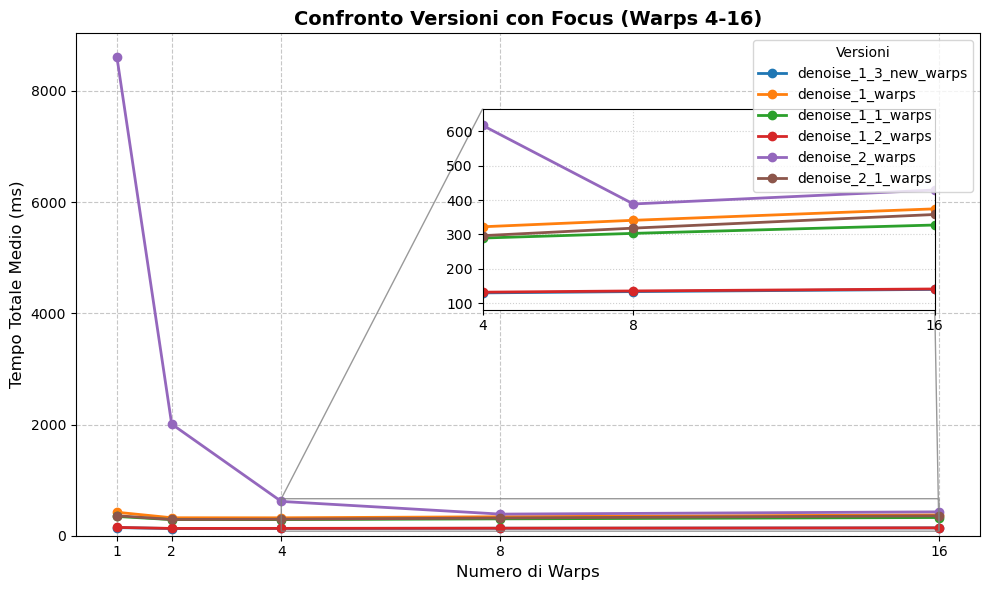

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. Array (lista) di file CSV in input
csv_files = [
    'denoise_1_3_new_warps.csv',
    'denoise_1_warps.csv',
    'denoise_1_1_warps.csv',
    'denoise_1_2_warps.csv',
    'denoise_2_warps.csv',
    'denoise_2_1_warps.csv'
    # 'altro_file_versione_1_2.csv', # Scommenta e aggiungi qui gli altri file
    # 'altro_file_versione_1_1.csv'
]


warps_desiderati = [1, 2, 4, 8, 16]

# Parametri per l'area di focus (zoom)
zoom_x_min = 4
zoom_x_max = 16

# Dizionario per salvare i dati elaborati in memoria
dati_elaborati = {}

# --- 2. LETTURA E PREPARAZIONE DATI ---
print("Lettura file...")
for file_path in csv_files:
    try:
        df = pd.read_csv(file_path)
        df['warps'] = df['executable'].str.extract(r'w(\d+)$').astype(int)
        df = df[df['warps'].isin(warps_desiderati)]
        
        df_avg = df.groupby('warps')['total_ms'].mean().reset_index().sort_values('warps')
        label_name = os.path.splitext(os.path.basename(file_path))[0]
        
        dati_elaborati[label_name] = df_avg
        print(f"  - Caricato: {label_name}")
    except FileNotFoundError:
        print(f"  [!] Attenzione: File '{file_path}' non trovato. Saltato.")
    except Exception as e:
        print(f"  [!] Errore con '{file_path}': {e}")

# --- 3. GRAFICI SINGOLI CON ETICHETTE ---
print("\nGenerazione grafici singoli...")
for label, df_avg in dati_elaborati.items():
    plt.figure(figsize=(8, 5))
    plt.plot(df_avg['warps'], df_avg['total_ms'], marker='o', linestyle='-', linewidth=2, color='cornflowerblue')
    
    # Calcoliamo un offset del 2% rispetto al valore massimo per distanziare il testo dal punto
    y_offset = df_avg['total_ms'].max() * 0.02 
    
    for x, y in zip(df_avg['warps'], df_avg['total_ms']):
        plt.text(x, y + y_offset, f"{y:.1f}", 
                 ha='center', va='bottom', fontsize=9, fontweight='bold', color='black')
    
    plt.title(f'Tempo Totale: {label}', fontsize=12, fontweight='bold')
    plt.xlabel('Numero di Warps', fontsize=10)
    plt.ylabel('Tempo Totale Medio (ms)', fontsize=10)
    plt.xticks(warps_desiderati)
    
    # --- MODIFICA: Forziamo l'asse Y a partire da 0 ---
    plt.ylim(bottom=0, top=df_avg['total_ms'].max() + (y_offset * 4))
    
    plt.grid(axis='both', linestyle='--', alpha=0.7)
    
    nome_file_output = f"grafico_singolo_{label}.png"
    plt.tight_layout()
    plt.savefig(nome_file_output, dpi=300) 
    plt.close() 
    print(f"  - Salvato: {nome_file_output}")

# --- 4. GRAFICO RIASSUNTIVO CON FOCUS ---
if dati_elaborati:
    print("\nGenerazione grafico riassuntivo con focus...")
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    min_y_zoom = float('inf')
    max_y_zoom = float('-inf')
    
    for label, df_avg in dati_elaborati.items():
        ax.plot(df_avg['warps'], df_avg['total_ms'], marker='o', linestyle='-', linewidth=2, label=label)
        
        focus_data = df_avg[(df_avg['warps'] >= zoom_x_min) & (df_avg['warps'] <= zoom_x_max)]
        if not focus_data.empty:
            min_y_zoom = min(min_y_zoom, focus_data['total_ms'].min())
            max_y_zoom = max(max_y_zoom, focus_data['total_ms'].max())

    ax.set_title('Confronto Versioni con Focus (Warps 4-16)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Numero di Warps', fontsize=12)
    ax.set_ylabel('Tempo Totale Medio (ms)', fontsize=12)
    ax.set_xticks(warps_desiderati)
    
    # --- MODIFICA: Forziamo l'asse Y del grafico principale a partire da 0 ---
    ax.set_ylim(bottom=0)
    
    ax.grid(axis='both', linestyle='--', alpha=0.7)
    ax.legend(title='Versioni')

    # Riquadro dello Zoom (rimane invariato per mantenere l'ingrandimento effettivo)
    axins = ax.inset_axes([0.45, 0.45, 0.5, 0.4]) 
    
    for label, df_avg in dati_elaborati.items():
        axins.plot(df_avg['warps'], df_avg['total_ms'], marker='o', linestyle='-', linewidth=2)
    
    axins.set_xlim(zoom_x_min, zoom_x_max)
    margine_y = (max_y_zoom - min_y_zoom) * 0.1 if max_y_zoom != min_y_zoom else 1
    axins.set_ylim(min_y_zoom - margine_y, max_y_zoom + margine_y)
    
    axins.set_xticks([w for w in warps_desiderati if zoom_x_min <= w <= zoom_x_max])
    axins.grid(True, linestyle=':', alpha=0.6)
    
    ax.indicate_inset_zoom(axins, edgecolor="gray", alpha=0.8)

    plt.tight_layout()
    
    nome_riassunto = "grafico_riassuntivo_focus.png"
    plt.savefig(nome_riassunto, dpi=300)
    print(f"  - Salvato: {nome_riassunto}")
    
    plt.show()
else:
    print("Nessun dato valido elaborato, impossibile generare il grafico riassuntivo.")

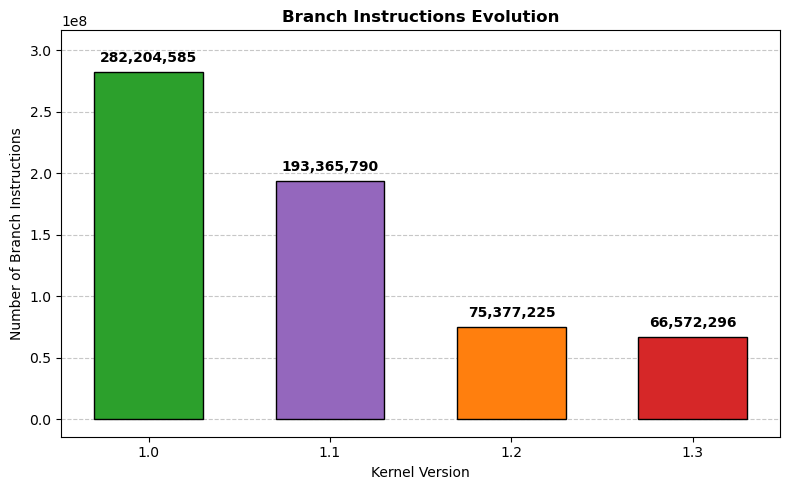

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Read data
df = pd.read_csv('branch_istructions.csv')

# 2. Clean data: remove dots and convert to integer
df['Branch Istructions'] = df['Branch Istructions'].str.replace('.', '').astype(int)
df['Version'] = df['Version'].astype(str)

# 3. Colors for each version (Green, Purple, Orange, Red)
colors = ['#2ca02c', '#9467bd', '#ff7f0e', '#d62728'] 

# 4. Create the figure
plt.figure(figsize=(8, 5))

# Create the bar chart
plt.bar(df['Version'], df['Branch Istructions'], 
        color=colors, edgecolor='black', width=0.6, zorder=2)

# 5. Add exact values on top of the bars
# Calculate a small offset to detach text from the top of the bar
y_offset = df['Branch Istructions'].max() * 0.02 

for x, y in zip(df['Version'], df['Branch Istructions']):
    # Format the number with commas for English standard
    text_label = f"{y:,}"
    plt.text(x, y + y_offset, text_label, ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

# 6. Aesthetic customization with English labels
plt.title('Branch Instructions Evolution', fontsize=12, fontweight='bold')
plt.xlabel('Kernel Version', fontsize=10)
plt.ylabel('Number of Branch Instructions', fontsize=10)

# Add grid only on the Y-axis for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=1)

# --- MODIFICA CHIAVE PER LA SCALA Y ---
# Invece di partire da 0 esatto, calcoliamo un margine inferiore negativo (es. -5% del valore massimo)
# per dare respiro alle colonne più basse
margine_inferiore = -(df['Branch Istructions'].max() * 0.05)
plt.ylim(bottom=margine_inferiore, top=df['Branch Istructions'].max() + (y_offset * 6))
# ---------------------------------------

# Optimize layout
plt.tight_layout()

# Save and show the image
plt.savefig('branch_instructions_histogram_en_spaced.png', dpi=300)
plt.show()

Lettura file per Focus Estremo...
  - Caricato: denoise_1_1_warps
  - Caricato: denoise_1_2_warps
  - Caricato: denoise_1_3_new_warps

Generato: grafico_focus_estremo.png


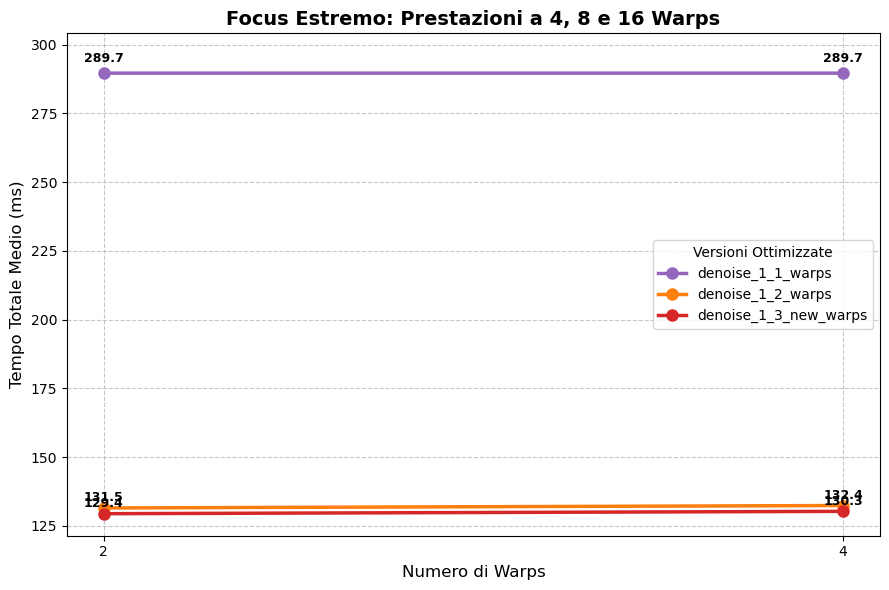

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. Array (lista) dei SOLI file veloci
csv_files_veloci = [
    'denoise_1_1_warps.csv',
    'denoise_1_2_warps.csv',
    'denoise_1_3_new_warps.csv'
]

# Concentriamoci solo sulla parte destra del grafico originale
warps_focus_estremo = [2,4]

# Dizionario per i dati
dati_veloci = {}

# --- 2. LETTURA DATI (Solo file selezionati e warps selezionati) ---
print("Lettura file per Focus Estremo...")
for file_path in csv_files_veloci:
    try:
        df = pd.read_csv(file_path)
        df['warps'] = df['executable'].str.extract(r'w(\d+)$').astype(int)
        
        # Filtriamo subito per i warps che ci interessano (4, 8, 16)
        df = df[df['warps'].isin(warps_focus_estremo)]
        
        df_avg = df.groupby('warps')['total_ms'].mean().reset_index().sort_values('warps')
        label_name = os.path.splitext(os.path.basename(file_path))[0]
        
        dati_veloci[label_name] = df_avg
        print(f"  - Caricato: {label_name}")
    except FileNotFoundError:
        print(f"  [!] File '{file_path}' non trovato.")
    except Exception as e:
        print(f"  [!] Errore: {e}")

# --- 3. CREAZIONE GRAFICO FOCUS ESTREMO ---
if dati_veloci:
    plt.figure(figsize=(9, 6))
    
    # Assegniamo colori specifici per riconoscerle meglio
    colori = ['#9467bd', '#ff7f0e', '#d62728'] # Viola, Arancione, Rosso
    
    for (label, df_avg), colore in zip(dati_veloci.items(), colori):
        plt.plot(df_avg['warps'], df_avg['total_ms'], 
                 marker='o', markersize=8, linestyle='-', linewidth=2.5, 
                 label=label, color=colore)
        
        # Aggiungiamo le etichette per ogni singolo punto in questo focus
        y_offset = df_avg['total_ms'].max() * 0.01
        for x, y in zip(df_avg['warps'], df_avg['total_ms']):
            plt.text(x, y + y_offset, f"{y:.1f}", 
                     ha='center', va='bottom', fontsize=9, fontweight='bold')

    plt.title('Focus Estremo: Prestazioni a 4, 8 e 16 Warps', fontsize=14, fontweight='bold')
    plt.xlabel('Numero di Warps', fontsize=12)
    plt.ylabel('Tempo Totale Medio (ms)', fontsize=12)
    
    # Forziamo l'asse X a mostrare solo 4, 8 e 16
    plt.xticks(warps_focus_estremo)
    
    # Lasciamo che l'asse Y si adatti ai dati per massimizzare il dettaglio visivo,
    # ma diamo un po' di margine sopra per le etichette di testo.
    max_val = max(df['total_ms'].max() for df in dati_veloci.values())
    plt.ylim(top=max_val * 1.05)

    plt.grid(axis='both', linestyle='--', alpha=0.7)
    plt.legend(title='Versioni Ottimizzate', loc='best')

    plt.tight_layout()
    
    nome_output = "grafico_focus_estremo.png"
    plt.savefig(nome_output, dpi=300)
    print(f"\nGenerato: {nome_output}")
    plt.show()
else:
    print("Nessun dato trovato per il focus estremo.")

Lettura file...
  - Caricato: denoise_1_3_new_warps
  - Caricato: denoise_1_warps
  - Caricato: denoise_1_1_warps
  - Caricato: denoise_1_2_warps
  - Caricato: denoise_2_warps
  - Caricato: denoise_2_1_warps

Generazione grafico riassuntivo base (Scala Automatica)...
  - Salvato: grafico_riassuntivo_base.png

Generazione grafico riassuntivo con Zoom Forzato (0-200ms)...
  - Salvato: grafico_riassuntivo_zoom_200ms.png


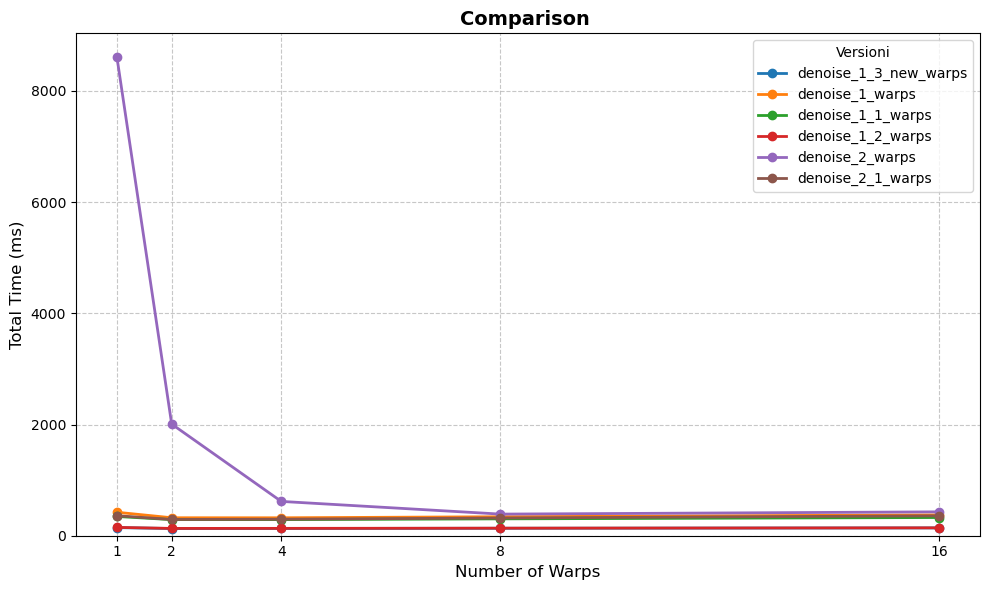

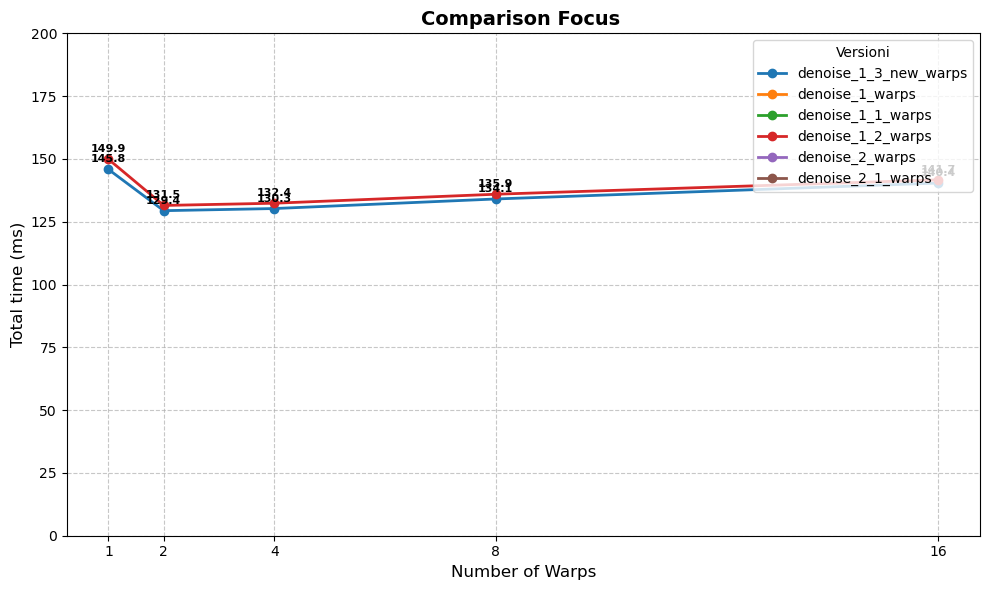

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. Array (lista) di tutti i file CSV in input
csv_files = [
    'denoise_1_3_new_warps.csv',
    'denoise_1_warps.csv',
    'denoise_1_1_warps.csv',
    'denoise_1_2_warps.csv',
    'denoise_2_warps.csv',
    'denoise_2_1_warps.csv'
]

warps_desiderati = [1, 2, 4, 8, 16]

# Dizionario per salvare i dati elaborati in memoria
dati_elaborati = {}

# --- 2. LETTURA E PREPARAZIONE DATI ---
print("Lettura file...")
for file_path in csv_files:
    try:
        df = pd.read_csv(file_path)
        df['warps'] = df['executable'].str.extract(r'w(\d+)$').astype(int)
        df = df[df['warps'].isin(warps_desiderati)]
        
        df_avg = df.groupby('warps')['total_ms'].mean().reset_index().sort_values('warps')
        label_name = os.path.splitext(os.path.basename(file_path))[0]
        
        dati_elaborati[label_name] = df_avg
        print(f"  - Caricato: {label_name}")
    except FileNotFoundError:
        print(f"  [!] Attenzione: File '{file_path}' non trovato. Saltato.")
    except Exception as e:
        print(f"  [!] Errore con '{file_path}': {e}")


if dati_elaborati:
    # --- 3. GRAFICO RIASSUNTIVO BASE (COMPLETO) ---
    print("\nGenerazione grafico riassuntivo base (Scala Automatica)...")
    
    plt.figure(figsize=(10, 6))
    
    for label, df_avg in dati_elaborati.items():
        plt.plot(df_avg['warps'], df_avg['total_ms'], marker='o', linestyle='-', linewidth=2, label=label)

    plt.title('Comparison ', fontsize=14, fontweight='bold')
    plt.xlabel('Number of Warps', fontsize=12)
    plt.ylabel('Total Time (ms)', fontsize=12)
    plt.xticks(warps_desiderati)
    plt.ylim(bottom=0) # Parte da zero, ma il massimo è automatico
    plt.grid(axis='both', linestyle='--', alpha=0.7)
    plt.legend(title='Versioni', loc='best')

    plt.tight_layout()
    nome_riassunto_base = "grafico_riassuntivo_base.png"
    plt.savefig(nome_riassunto_base, dpi=300)
    print(f"  - Salvato: {nome_riassunto_base}")
    # plt.show() # Scommenta se vuoi vederlo apparire a schermo prima di continuare


    # --- 4. GRAFICO RIASSUNTIVO ZOOM FORZATO (0-200ms) ---
    print("\nGenerazione grafico riassuntivo con Zoom Forzato (0-200ms)...")
    
    plt.figure(figsize=(10, 6))
    
    for label, df_avg in dati_elaborati.items():
        plt.plot(df_avg['warps'], df_avg['total_ms'], marker='o', linestyle='-', linewidth=2, label=label)
        
        # Aggiungiamo le etichette solo per i punti che cadono dentro il nostro zoom (sotto i 200ms)
        # Così evitiamo di stampare numeri che finiscono fuori dall'immagine
        for x, y in zip(df_avg['warps'], df_avg['total_ms']):
            if y <= 200:
                plt.text(x, y + 2, f"{y:.1f}", ha='center', va='bottom', fontsize=8, fontweight='bold')

    plt.title('Comparison Focus ', fontsize=14, fontweight='bold')
    plt.xlabel('Number of Warps', fontsize=12)
    plt.ylabel('Total time (ms)', fontsize=12)
    plt.xticks(warps_desiderati)
    
    # --- IL CUORE DELLA MODIFICA: TAGLIO FORZATO DELL'ASSE Y ---
    plt.ylim(0, 200) 
    # -----------------------------------------------------------
    
    plt.grid(axis='both', linestyle='--', alpha=0.7)
    
    # Spostiamo la legenda fuori dal grafico o in alto a destra se c'è spazio
    plt.legend(title='Versioni', loc='upper right')

    plt.tight_layout()
    nome_riassunto_zoom = "grafico_riassuntivo_zoom_200ms.png"
    plt.savefig(nome_riassunto_zoom, dpi=300)
    print(f"  - Salvato: {nome_riassunto_zoom}")
    
    # Mostriamo solo l'ultimo grafico a schermo per non bloccare il programma
    plt.show() 

else:
    print("Nessun dato valido elaborato.")